# Text-conditioned emoji diffusion

`train_cond.ipynb` conditions on one of 8 groups. This one conditions on the
**emoji name**, through a frozen CLIP text embedding:

```python
emb = time_mlp(t) + text_proj(text_bank[y])
```

Why not a plain `nn.Embedding` over names? Because openmoji names are unique —
exactly one image each — so a learned table per name has nothing to generalise
from and can only memorise. CLIP places "grinning face" near "winking face", so
the model learns *face-ness* from every smiley at once. It also means the
conditioning space is shared with CLIP, so **sampling accepts any prompt**, not
just the 500 names it trained on.

CLIP is never trained. The bank is computed once and frozen; the only new thing
that learns is `text_proj`, ~198k parameters (1.2% of the model).

Sections: the text bank and its retrieval accuracy (§2), training (§4), sampling
by name (§5) and by free prompt (§6), metrics (§8), and a standalone LLM
decomposition demo (§9) — not wired into the pipeline yet.

In [1]:
import requests
from IPython import get_ipython

TELEGRAM_TOKEN = "8819911268:AAG0RJ5VZ4NeiKbKME52_3DhNdv2rHAHwRQ"
CHAT_ID = "7360076634"

def telegram_on_error(shell, etype, evalue, tb, tb_offset=None):
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)
    
    msg = f"⚠️ *Jupyter Cell Failed*\n*Error:* `{etype.__name__}`\n*Message:* {evalue}"
    url = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage"
    requests.post(url, data={"chat_id": CHAT_ID, "text": msg, "parse_mode": "Markdown"})

get_ipython().set_custom_exc((Exception,), telegram_on_error)

In [2]:
import os
print("Process ID (PID):", os.getpid())

Process ID (PID): 120910


## 0. Setup

In [3]:
import json
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import emoji_text
import metrics
from dataloader import OPENMOJI_500, ConditionedEmojiDataset
from diffusion import Diffusion
from runlog import Run, plot_losses, show_grid
from trainer import generate, train
from unet_text import TextConditionedUNet

RUN_NAME = "text_500"
SUBSET = OPENMOJI_500

# --- diffusion ---
T = 1000

# --- training ---
STEPS = 30_000
BATCH = 32
LR = 2e-4
EMA_DECAY = 0.999
TEXT_DROPOUT = 0.1        # fraction of prompts replaced by the null embedding (enables CFG)
LOG_EVERY = 500
CHECKPOINT_EVERY = 1_000
PREVIEW_EVERY = 3_000
NUM_WORKERS = 2

# --- text bank ---
USE_KEYWORDS = True       # fold openmoji's `description` keywords into each prompt

# --- sampling ---
DDIM_STEPS = 100
HERO_DDIM_STEPS = None    # None -> full 1000-step ancestral for the final figures
GUIDANCE = 3.0            # text conditioning needs more guidance than 8-class conditioning
GUIDANCE_SWEEP = [1.0, 2.0, 3.0, 5.0, 7.5]

# Names to watch during training, and to draw in the final figure.
PREVIEW_NAMES = ["pizza", "dog face", "rocket", "grinning face",
                 "soccer ball", "red apple", "airplane", "guitar"]

# Free-text prompts — none of these are emoji names.
PROMPTS = ["a happy face", "something to eat", "a fast vehicle", "a wild animal",
           "a musical instrument", "the sun", "a scary monster", "love"]

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

QUICK = False
if QUICK:
    STEPS, PREVIEW_EVERY, CHECKPOINT_EVERY, LOG_EVERY = 20, 10, 10, 5
    DDIM_STEPS, HERO_DDIM_STEPS = 10, 10
    GUIDANCE_SWEEP = [1.0, 3.0]
    NUM_WORKERS = 0

torch.manual_seed(SEED)
print(f"device: {DEVICE}  |  torch {torch.__version__}  |  quick mode: {QUICK}")

device: cuda  |  torch 2.0.1+cu118  |  quick mode: False


## 1. Data — 500 curated emoji, one class per name

`make_subsets.py` grows the curated 200 up to 500 by filling round-robin across
groups and subgroups, after dropping subgroups that would poison text
conditioning: keycaps, arrows, clock faces, colour swatches and the 25
near-identical `family: ...` variants. Those teach the model that very different
prompts map to nearly the same picture.

In [4]:
if not Path(SUBSET, "metadata.csv").exists():
    subprocess.run(["python", "make_subsets.py"], check=True)

# label_col="name" -> one class per emoji, 500 of them.
ds = ConditionedEmojiDataset.from_dir(SUBSET, label_col="name")

names = ds.classes
by_name = {row["name"]: row for row in ds.meta}
descriptions = [by_name[n]["description"] for n in names]
groups = sorted({row["group"] for row in ds.meta})

print(f"{len(ds)} images, {ds.num_classes} names, {len(groups)} groups")
print(f"images per name: {len(ds) / ds.num_classes:.1f}")
print(f"example: {names[0]!r} — {descriptions[0][:60]}")

missing = [n for n in PREVIEW_NAMES if n not in by_name]
assert not missing, f"preview names not in the subset: {missing}"

500 images, 500 names, 8 groups
images per name: 1.0
example: '1st place medal' — 1st, first, gold, medal, place


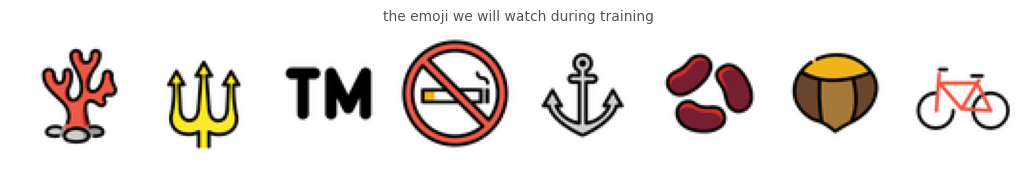

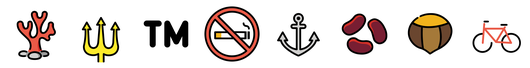

In [5]:
real_images = torch.stack([ds[i][0] for i in range(len(ds))])
real_labels = torch.tensor(ds.labels)              # index into `names`
name_to_idx = {n: i for i, n in enumerate(names)}

preview_labels = torch.tensor([name_to_idx[n] for n in PREVIEW_NAMES])
show_grid(real_images[preview_labels], ncols=8, title="the emoji we will watch during training")

## 2. The CLIP text bank

One row per name plus a trailing null row (the empty prompt) for
classifier-free guidance. Cached to disk — after the first build, CLIP is not
loaded again during training.

Two diagnostics before spending hours on training, both free:

- **Confusable pairs.** Names at cosine ~0.99 are the *same instruction* to a
  frozen encoder. No amount of training separates them; this is the model's
  resolution limit, known up front.
- **Retrieval accuracy.** openmoji's `description` keywords give a labelled test
  set for nothing: query with the keywords, check the right name comes back.
  This measures the prompt→name stage independently of image quality.

In [6]:
clip = metrics.ClipFeatures(device=DEVICE)

cache = Path(SUBSET) / ("clip_bank_keywords.pt" if USE_KEYWORDS else "clip_bank.pt")
bank = emoji_text.build_bank(
    names,
    descriptions if USE_KEYWORDS else None,
    clip=clip,
    cache_path=cache,
)
print(f"bank: {tuple(bank.shape)}  (last row = null prompt)  cached at {cache}")

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bank: (501, 512)  (last row = null prompt)  cached at datasets/openmoji_500/clip_bank_keywords.pt


In [7]:
print("most confusable name pairs — the model cannot be expected to separate these:")
for a, b, sim in emoji_text.confusable_pairs(bank, names, top=10):
    print(f"  {sim:.3f}  {a:<28} ~  {b}")

most confusable name pairs — the model cannot be expected to separate these:
  0.979  beaming face with smiling eyes ~  grinning face with smiling eyes
  0.974  grinning face with big eyes  ~  grinning face with smiling eyes
  0.972  grinning face                ~  grinning face with smiling eyes
  0.963  smiling face with smiling eyes ~  beaming face with smiling eyes
  0.959  double curly loop            ~  curly loop
  0.958  man genie                    ~  genie
  0.958  cloud with lightning and rain ~  cloud with lightning
  0.956  slightly smiling face        ~  smiling face
  0.955  kissing face with smiling eyes ~  kissing face
  0.952  closed mailbox with raised flag ~  closed mailbox with lowered flag


In [8]:
# Query with the keyword lists, answer is the name. Chance is 1/500 = 0.2%.
labelled = [(by_name[n]["description"], n) for n in names if by_name[n]["description"].strip()]
queries, targets = [list(x) for x in zip(*labelled)]

retrieval = emoji_text.retrieval_accuracy(bank, names, queries, targets, clip)
print(json.dumps(retrieval, indent=2))

/usr/local/lib/python3.8/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


{
  "top1": 0.9096385836601257,
  "top5": 0.9678714871406555,
  "top10": 0.9819276928901672,
  "mean_rank": 1.6164658069610596,
  "n_queries": 498,
  "n_candidates": 500
}


In [9]:
# The prompt -> name stage, on free text. It can only ever return a real name.
for prompt in PROMPTS:
    hits = emoji_text.match(prompt, bank, names, clip, k=3)[0]
    print(f"  {prompt!r:<26} -> " + ",  ".join(f"{n} ({s:.2f})" for n, s in hits))

  'a happy face'             -> slightly smiling face (0.81),  smiling face (0.80),  beaming face with smiling eyes (0.78)
  'something to eat'         -> sparkle (0.63),  copyright (0.61),  plus (0.60)
  'a fast vehicle'           -> automobile (0.63),  motorcycle (0.62),  sparkle (0.58)
  'a wild animal'            -> bird (0.66),  fox (0.63),  bug (0.62)
  'a musical instrument'     -> guitar (0.67),  butterfly (0.64),  banjo (0.64)
  'the sun'                  -> sun (0.66),  sparkle (0.64),  eye (0.63)
  'a scary monster'          -> zombie (0.64),  alien (0.62),  eye (0.61)
  'love'                     -> sparkle (0.66),  plus (0.61),  part alternation mark (0.60)


## 3. Model

`TextConditionedUNet` holds the bank as a **buffer**, not a parameter: it moves
with `.to(device)` and is saved inside the checkpoint (so a checkpoint is
self-contained), but no gradient ever reaches it. `forward` takes either int64
indices into the bank (training) or raw float embeddings (free prompts).

In [10]:
def build_model():
    torch.manual_seed(SEED)
    return TextConditionedUNet(bank, text_dropout=TEXT_DROPOUT)


model = build_model()
params = sum(p.numel() for p in model.parameters())
proj = sum(p.numel() for p in model.text_proj.parameters())
print(f"params: {params / 1e6:.2f}M  (text_proj: {proj:,} = {100 * proj / params:.2f}%)")
print(f"names: {model.num_classes}  null index: {model.null_class}  text dim: {model.text_dim}")

params: 15.92M  (text_proj: 198,144 = 1.24%)
names: 500  null index: 500  text dim: 512


## 4. Training

Same loop as the conditional run — the only change is what `y` means. Weights
are rewritten to `runs/text_500/ckpt.pt` every `CHECKPOINT_EVERY` steps, so an
interrupted run loses at most that much.

step    500 | epoch    33.3 | loss 0.0701 |   0.5 min
step   1000 | epoch    66.7 | loss 0.0241 |   1.1 min
step   1500 | epoch   100.0 | loss 0.0178 |   1.6 min
step   2000 | epoch   133.3 | loss 0.0159 |   2.1 min
step   2500 | epoch   166.7 | loss 0.0140 |   2.7 min
step   3000 | epoch   200.0 | loss 0.0126 |   3.2 min


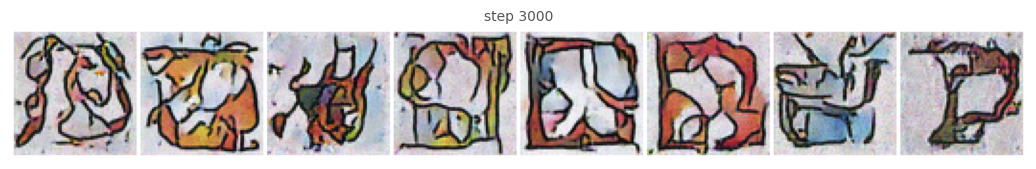

step   3500 | epoch   233.3 | loss 0.0120 |   3.8 min
step   4000 | epoch   266.7 | loss 0.0115 |   4.3 min
step   4500 | epoch   300.0 | loss 0.0109 |   4.8 min
step   5000 | epoch   333.3 | loss 0.0098 |   5.3 min
step   5500 | epoch   366.7 | loss 0.0097 |   5.9 min
step   6000 | epoch   400.0 | loss 0.0090 |   6.4 min


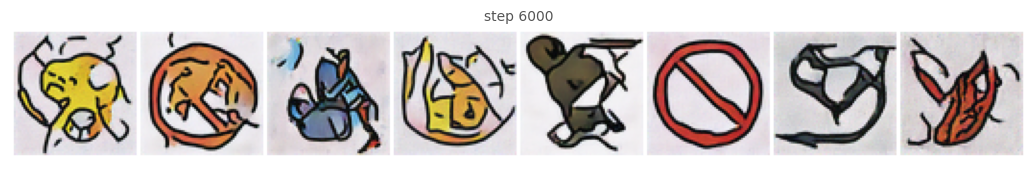

step   6500 | epoch   433.3 | loss 0.0085 |   7.0 min
step   7000 | epoch   466.7 | loss 0.0081 |   7.5 min
step   7500 | epoch   500.0 | loss 0.0076 |   8.0 min
step   8000 | epoch   533.3 | loss 0.0073 |   8.5 min
step   8500 | epoch   566.7 | loss 0.0064 |   9.1 min
step   9000 | epoch   600.0 | loss 0.0064 |   9.6 min


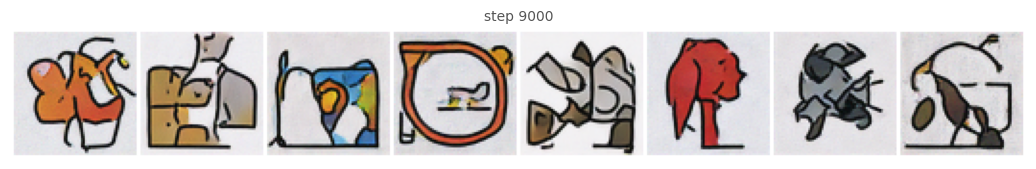

In [ ]:
run = Run(RUN_NAME, config={
    "dataset": SUBSET, "n_images": len(ds), "n_names": ds.num_classes,
    "conditioning": "clip-text", "use_keywords": USE_KEYWORDS,
    "steps": STEPS, "batch_size": BATCH, "lr": LR, "timesteps": T,
    "ema_decay": EMA_DECAY, "text_dropout": TEXT_DROPOUT,
    "guidance": GUIDANCE, "seed": SEED, "device": DEVICE, "quick": QUICK,
    "retrieval": retrieval,
})

model, ema, losses, diffusion = train(
    build_model(), ds, run,
    steps=STEPS, batch_size=BATCH, lr=LR, timesteps=T,
    ema_decay=EMA_DECAY, log_every=LOG_EVERY,
    checkpoint_every=CHECKPOINT_EVERY,
    preview_every=PREVIEW_EVERY, preview_labels=preview_labels,
    preview_ddim_steps=DDIM_STEPS, guidance_scale=GUIDANCE,
    num_workers=NUM_WORKERS, device=DEVICE, seed=SEED,
    on_preview=lambda step, imgs, lbls: show_grid(imgs, ncols=8, title=f"step {step}"),
)

In [ ]:
plot_losses(losses, k=max(1, STEPS // 100), title=f"{RUN_NAME} — training loss", path=run.path("loss.png"))

## 5. Sampling by name

Generated on the top row, the real training emoji underneath. These names *were*
in training, so this measures how well the model renders a known instruction.

In [23]:
def show_pairs(generated, reference, labels, title, path=None, scale=1.1):
    """Generated on top, the reference image below, one column per label."""
    fig, axes = plt.subplots(2, len(labels), figsize=(scale * len(labels), 2.9), squeeze=False)
    for col, (image, ref, label) in enumerate(zip(generated, reference, labels)):
        for row, img in enumerate((image, ref)):
            axes[row][col].imshow(((img.cpu().clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy())
            axes[row][col].axis("off")
        axes[0][col].set_title(names[label], fontsize=7, color="#555")
    for row, tag in enumerate(("generated", "training")):
        axes[row][0].text(-0.2, 0.5, tag, transform=axes[row][0].transAxes,
                          ha="right", va="center", fontsize=8, color="#555")
    fig.suptitle(title, fontsize=10, color="#555")
    plt.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


named = generate(ema, diffusion, preview_labels, guidance_scale=GUIDANCE,
                 ddim_steps=HERO_DDIM_STEPS, device=DEVICE)
run.save_grid(named, "by_name.png", ncols=8)
show_pairs(named, real_images[preview_labels], preview_labels.tolist(),
           f"{RUN_NAME} — sampled by name (guidance {GUIDANCE})",
           path=run.samples_dir / "by_name_pairs.png")

NameError: name 'ema' is not defined

## 6. Sampling by free prompt

The payoff of a shared embedding space: none of these strings is an emoji name,
and the model never saw them. Each column is one prompt; the rows are different
noise seeds, so spread within a column is the model's own variety.

In [ ]:
PER_PROMPT = 4

prompt_emb = emoji_text.encode_prompts(PROMPTS, clip)          # (P, 512)
y = prompt_emb.repeat_interleave(PER_PROMPT, dim=0)            # float conditioning
free = generate(ema, diffusion, y, guidance_scale=GUIDANCE,
                ddim_steps=HERO_DDIM_STEPS, device=DEVICE)

fig, axes = plt.subplots(PER_PROMPT, len(PROMPTS),
                         figsize=(1.15 * len(PROMPTS), 1.15 * PER_PROMPT + 0.9), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for col, prompt in enumerate(PROMPTS):
    for row in range(PER_PROMPT):
        img = free[col * PER_PROMPT + row]
        axes[row][col].imshow(((img.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy())
    axes[0][col].set_title(prompt.replace(" ", "\n"), fontsize=7, color="#555")
fig.suptitle(f"{RUN_NAME} — sampled from free text, never seen in training", fontsize=10, color="#555")
plt.tight_layout()
fig.savefig(run.samples_dir / "by_prompt.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# What each prompt is nearest to in the training vocabulary — the sanity check
# for the figure above. If a prompt looks wrong, this usually explains why.
for prompt in PROMPTS:
    hits = emoji_text.match(prompt, bank, names, clip, k=3)[0]
    print(f"  {prompt!r:<26} -> " + ",  ".join(n for n, _ in hits))

## 7. Guidance

Text conditioning is weaker per-prompt than 8-way class conditioning — 500
instructions share one projection — so it usually needs a higher guidance scale.
Too high and every sample of a prompt collapses to the same picture.

In [ ]:
sweep = []
for scale in GUIDANCE_SWEEP:
    torch.manual_seed(SEED)
    images = generate(ema, diffusion, preview_labels, guidance_scale=scale,
                      ddim_steps=DDIM_STEPS, device=DEVICE)

    feats = clip.encode_images(images).cpu()
    accuracy, _, _ = metrics.zero_shot_accuracy(feats, bank[: len(names)], preview_labels)
    spread = metrics.diversity(feats, normalized=True)

    sweep.append({"guidance_scale": scale, "name_accuracy": accuracy,
                  "clip_score": metrics.clip_score(feats, bank[preview_labels]),
                  "diversity": spread})
    run.save_grid(images, f"guidance_{scale:g}.png", ncols=8)
    print(f"scale {scale:>4g}: name acc {accuracy:.3f}  clip score {sweep[-1]['clip_score']:.2f}  diversity {spread:.3f}")

run.write_json("guidance_sweep.json", sweep)

## 8. Metrics

Two levels, because "which of 500 names is this?" and "does this look like an
emoji at all?" are different questions:

- **Distribution metrics** (FID/KID/CMMD, precision/recall) over all 500
  generated vs all 500 real, with the emoji's *group* as the class label so
  per-class numbers stay meaningful with 8 buckets rather than 500.
- **Name-level conditioning**: CLIP score against the sample's own name prompt,
  and top-1/top-5 accuracy over all 500 names. Chance is 0.2%.

In [11]:
inception = metrics.InceptionFeatures(DEVICE)

t0 = time.time()
all_labels = torch.arange(len(names))
fake_images = generate(ema, diffusion, all_labels, guidance_scale=GUIDANCE,
                       ddim_steps=DDIM_STEPS, device=DEVICE)
print(f"generated {len(fake_images)} samples, one per name, in {(time.time() - t0) / 60:.1f} min")
run.save_grid(fake_images, "all_names.png", ncols=25)

NameError: name 'ema' is not defined

In [ ]:
group_idx = {g: i for i, g in enumerate(groups)}
group_of = torch.tensor([group_idx[by_name[n]["group"]] for n in names])

scores = metrics.evaluate(
    real_images, group_of[real_labels], fake_images, group_of[all_labels],
    groups, device=DEVICE, inception=inception, clip=clip,
)

# Name-level conditioning, over all 500 names at once.
fake_feats = clip.encode_images(fake_images).cpu()
name_bank = bank[: len(names)]
ranks = (fake_feats @ name_bank.T).argsort(dim=-1, descending=True)
hit = (ranks == all_labels[:, None]).float().argmax(dim=-1)

scores.update({
    "name_clip_score": metrics.clip_score(fake_feats, name_bank[all_labels]),
    "name_top1": float((hit < 1).float().mean()),
    "name_top5": float((hit < 5).float().mean()),
    "name_top10": float((hit < 10).float().mean()),
    "name_chance": 1 / len(names),
    "guidance_scale": GUIDANCE,
    "retrieval_text_only": retrieval,
})
run.save_metrics(scores)
print(json.dumps(scores, indent=2))

## 9. LLM decomposition (standalone)

The one job CLIP retrieval cannot do: splitting a sentence into several emoji.
A single CLIP embedding of *"a cat eating pizza at the beach"* blends into one
concept and can never return three names.

This section is **not pipelined** into generation yet — it shows the LLM
producing phrases and CLIP resolving each to a real name. Note the division of
labour: the LLM may say anything at all, and the matcher still returns a name
that exists, so hallucination cannot reach the diffusion model.

Needs `python download_llm.py` and `transformers`; the cell skips cleanly if
either is missing.

In [ ]:
import emoji_llm

SENTENCES = ["a cat eating pizza at the beach",
             "celebrating a birthday with friends",
             "rainy day at the office"]

try:
    llm, tokenizer = emoji_llm.load(emoji_llm.DEFAULT_MODEL_DIR, DEVICE)
except (FileNotFoundError, ImportError) as exc:
    llm = None
    print(f"skipped: {exc}")

if llm is not None:
    for sentence in SENTENCES:
        phrases = emoji_llm.decompose(sentence, llm, tokenizer, DEVICE)
        matched = [emoji_text.match(p, bank, names, clip, k=1)[0][0][0] for p in phrases]
        print(f"{sentence!r}")
        print(f"   LLM      -> {phrases}")
        print(f"   matched  -> {matched}\n")

## 10. Saved results

In [ ]:
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

config = run.read_json("config.json")
lines = [
    "# Text-conditioned emoji diffusion — results",
    "",
    f"Generated {time.strftime('%Y-%m-%d %H:%M')} on {DEVICE}"
    + ("  **(QUICK mode — placeholder numbers)**" if QUICK else ""),
    "",
    f"- dataset: `{SUBSET}` — {len(ds)} images, {ds.num_classes} names",
    f"- conditioning: frozen CLIP text embeddings"
    f"{' + description keywords' if USE_KEYWORDS else ''}",
    f"- steps: {config.get('steps_completed', STEPS)} at batch {BATCH}"
    f" — {config.get('train_minutes', float('nan')):.1f} min",
    f"- final loss: {config.get('final_loss', float('nan')):.4f}",
    "",
    "## Prompt -> name retrieval (text only, no images)",
    "",
    f"top-1 {retrieval['top1']:.3f} | top-5 {retrieval['top5']:.3f} | "
    f"top-10 {retrieval['top10']:.3f} over {retrieval['n_candidates']} candidates",
    "",
    "## Generation metrics",
    "",
    "| metric | value |",
    "| --- | --- |",
]
for key in ("fid", "kid_mean", "cmmd", "precision", "recall", "clip_score",
            "clip_accuracy", "clip_accuracy_real", "name_clip_score",
            "name_top1", "name_top5", "name_chance",
            "nn_similarity_mean", "diversity_fake", "diversity_real"):
    value = scores.get(key)
    if isinstance(value, (int, float)):
        lines.append(f"| {key} | {value:.4f} |")

lines += ["", "## Guidance sweep", "", "| scale | name accuracy | CLIP score | diversity |", "| --- | --- | --- | --- |"]
lines += [f"| {s['guidance_scale']:g} | {s['name_accuracy']:.3f} | {s['clip_score']:.2f} | {s['diversity']:.3f} |"
          for s in sweep]
lines += ["", "## Figures", ""] + [f"- `{p}`" for p in sorted(run.dir.rglob("*.png"))]

with open(RESULTS / f"summary_{RUN_NAME}.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print("\n".join(lines[:22]))
print(f"\nwrote {RESULTS / f'summary_{RUN_NAME}.md'}")

### Caveats

- **Frozen CLIP is the ceiling.** Names it cannot separate (§2) are names the
  model cannot separate. That is a property of the encoder, not of training.
- **500 images is very little** for 500 distinct instructions. Expect the model
  to capture colour, silhouette and category far better than fine detail.
- **FID at n=500 is still biased.** KID and CMMD are the defensible distribution
  numbers; the name-level accuracy is the conditioning number that matters.
- **`clip_accuracy_real` is the ceiling** for group accuracy — CLIP is an
  imperfect judge of 64x64 pictograms, so read generated scores against it.

## 11. Playground

Edit `PROMPT` below and re-run this cell.

It works on a fresh kernel: run §0 (setup) and §2 (the text bank), then this —
it restores the trained weights from `runs/text_500/ckpt.pt` if they are not
already in memory, so you do not have to retrain to generate.

The nearest training names printed underneath are the diagnostic. If an image
looks wrong they usually explain why: the prompt landed somewhere unexpected in
CLIP space.

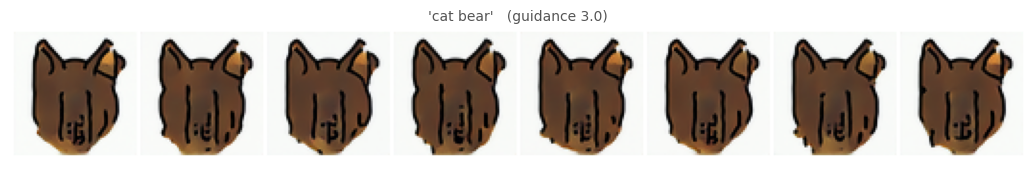

nearest training names: bear (0.63),  cat face (0.61),  teddy bear (0.60),  boar (0.59),  crying cat (0.58)
saved -> runs/text_500/samples/playground_cat_bear.png


In [59]:
# ── edit me ───────────────────────────────────────────────────────────
PROMPT         = "a smiling face with sunglasses"
PROMPT         = "red heart"
# PROMPT         = "woman in dress"
PROMPT         = "crying face"
PROMPT         = "guy wearing a hat"
PROMPT         = "pink cloud"
PROMPT         = "white cloud"
PROMPT         = "three color flag"
PROMPT         = "sugarcane"
PROMPT         = "crying plant"
PROMPT         = "sad lion"
PROMPT         = "angry woman"
PROMPT         = "relaxed tiger"
PROMPT         = "cat bear"
PROMPT         = "pizza hamburger"
PROMPT         = "black apple"
PROMPT         = "ball"
PROMPT         = "sport"
PROMPT         = "recreational activity"
PROMPT         = "recreational activity"
PROMPT         = "guy wearing a hat"
PROMPT         = "crazy frog"
PROMPT         = "hugging face"
PROMPT         = "blue house"
PROMPT         = "blue heart"
PROMPT         = "recreational activity"
PROMPT         = "cat beer"
PROMPT         = "cat bear"
# PROMPT         = "seahorse" # ovo je za demo
# PROMPT         = "merman"
# PROMPT         = "aquaman"
N_IMAGES       = 8
GUIDANCE_SCALE = GUIDANCE
SAMPLE_STEPS   = None      # None -> full 1000-step ancestral; an int -> DDIM
SEED           = None      # set an int to reproduce an image you liked
# ──────────────────────────────────────────────────────────────────────

import re

playground_run = Run(RUN_NAME)

# Restore the trained model if this is a fresh kernel.
if "ema" not in globals():
    checkpoint = playground_run.load_checkpoint(map_location=DEVICE)
    ema = TextConditionedUNet(bank, text_dropout=TEXT_DROPOUT).to(DEVICE)
    ema.load_state_dict(checkpoint["ema"])
    ema.eval()
    diffusion = Diffusion(timesteps=T, device=DEVICE)
    print(f"restored EMA weights from step {checkpoint['step']}")

# The checkpoint carries the bank it was trained on. If that disagrees with the
# bank in memory, prompts are being encoded into a space the model never saw —
# which is exactly how a whole run once got trained on random vectors.
if not torch.allclose(ema.text_bank.cpu().float(), bank.float(), atol=1e-4):
    print("WARNING: this checkpoint was trained on a DIFFERENT text bank.")
    print("         Free-text prompts will not work until you retrain on the current one.")

if SEED is not None:
    torch.manual_seed(SEED)

y = emoji_text.encode_prompts(PROMPT, clip).repeat(N_IMAGES, 1)
images = generate(ema, diffusion, y, guidance_scale=GUIDANCE_SCALE,
                  ddim_steps=SAMPLE_STEPS, device=DEVICE)

slug = re.sub(r"[^a-z0-9]+", "_", PROMPT.lower()).strip("_")[:40] or "prompt"
saved = playground_run.samples_dir / f"playground_{slug}.png"

show_grid(images, ncols=min(N_IMAGES, 8),
          title=f"{PROMPT!r}   (guidance {GUIDANCE_SCALE})", path=saved)

nearest = emoji_text.match(PROMPT, bank, names, clip, k=5)[0]
print("nearest training names: " + ",  ".join(f"{n} ({s:.2f})" for n, s in nearest))
print(f"saved -> {saved}")

## 12. Train more

Continues this run rather than starting a new one: it loads
`runs/text_500/ckpt.pt` if no trained model is in memory, runs `EXTRA_STEPS`
further steps, and extends the step numbering and loss history instead of
resetting them to zero.

Every round ends saved. `ckpt.pt` is the rolling checkpoint and now carries the
optimiser state too, so the next round resumes with Adam's moments intact rather
than restarting them. With `SNAPSHOT = True` the round also leaves an immutable
`ckpt_step<N>.pt` next to it, so a state you liked is never overwritten by a
later round.

Run §0, §1 and §2 first — this needs `ds`, `bank` and `preview_labels`.

In [ ]:
# ── edit me ───────────────────────────────────────────────────────────
EXTRA_STEPS         = 10_000
LEARNING_RATE       = LR
SNAPSHOT            = True    # keep this round's weights under their own name
ALLOW_BANK_MISMATCH = False   # see the guard below before setting this True
# ──────────────────────────────────────────────────────────────────────

training_run = Run(RUN_NAME)

# Load from disk unless a trained model is already in memory.
if not {"model", "ema"} <= globals().keys():
    checkpoint = training_run.load_checkpoint(map_location=DEVICE)

    model = TextConditionedUNet(bank, text_dropout=TEXT_DROPOUT).to(DEVICE)
    model.load_state_dict(checkpoint["model"])

    ema = TextConditionedUNet(bank, text_dropout=TEXT_DROPOUT).to(DEVICE)
    ema.load_state_dict(checkpoint["ema"])
    ema.requires_grad_(False)
    ema.eval()

    resume_step = checkpoint["step"]
    optimizer_state = checkpoint.get("opt")
    print(f"loaded weights from step {resume_step}" + ("" if optimizer_state else
          "  (no optimiser state in this checkpoint — Adam restarts, expect a brief loss bump)"))
else:
    resume_step = training_run.config.get("steps_completed", 0)
    optimizer_state = None
    print(f"continuing the model already in memory, at step {resume_step}")

# Training further on top of a different bank would extend a model whose
# conditioning space no longer means anything. Starting over is the fix.
if not torch.allclose(ema.text_bank.cpu().float(), bank.float(), atol=1e-4):
    problem = ("this checkpoint was trained on a DIFFERENT text bank, so resuming would "
               "extend a model whose conditioning no longer matches your prompts. "
               "Retrain from scratch (§4), or set ALLOW_BANK_MISMATCH = True to override.")
    if not ALLOW_BANK_MISMATCH:
        raise RuntimeError(problem)
    print("WARNING: " + problem)

model, ema, losses, diffusion = train(
    model, ds, training_run,
    steps=EXTRA_STEPS, batch_size=BATCH, lr=LEARNING_RATE, timesteps=T,
    ema_decay=EMA_DECAY, log_every=LOG_EVERY, checkpoint_every=CHECKPOINT_EVERY,
    preview_every=PREVIEW_EVERY, preview_labels=preview_labels,
    preview_ddim_steps=DDIM_STEPS, guidance_scale=GUIDANCE,
    num_workers=NUM_WORKERS, device=DEVICE, seed=SEED,
    ema=ema, start_step=resume_step, optimizer_state=optimizer_state,
    losses=training_run.load_losses(),
    on_preview=lambda step, imgs, lbls: show_grid(imgs, ncols=8, title=f"step {step}"),
)

total_steps = training_run.read_json("config.json")["steps_completed"]
if SNAPSHOT:
    print("snapshot ->", training_run.save_checkpoint(
        model, ema=ema, step=total_steps, filename=f"ckpt_step{total_steps:06d}.pt"))

plot_losses(losses, k=max(1, len(losses) // 100),
            title=f"{RUN_NAME} — {total_steps} steps total",
            path=training_run.path("loss.png"))

## 13. Run on the full augmented dataset

`text_500` had 500 names and exactly one image per name, so it had no way to do
anything except memorise — and `name_top1` of 0.006 against a chance of 0.002
says it did not even manage that well. This run uses
`datasets/openmoji_aug_geom`: all 1321 emoji, 8 geometric variants each, 10,568
images. The same name now arrives as eight different pictures.

Geometry only, deliberately. The prompts are built from the emoji's own name and
keyword list, and plenty of those names carry a colour — "red heart", "green
apple", "blue book". Hue-shifting the pixels while keeping the caption would
make the training pair a lie. The colour-augmented twin exists for the
class-conditional notebook, where the label is a group and hue is irrelevant.

In [13]:
from dataloader import train_val_split
from runlog import load_metrics

AUG_NAME = "text_aug_full"
AUG_GEOM = "datasets/openmoji_aug_geom"

AUG_STEPS = 60_000        # 7926 train images at batch 32 -> ~247 steps/epoch
AUG_BATCH = 32
AUG_LOG_EVERY = 500
AUG_VAL_EVERY = 500
AUG_VAL_IMAGES = 512
AUG_CHECKPOINT_EVERY = 2_000
AUG_PREVIEW_EVERY = 5_000

# Stacking all 10,568 images is ~520 MB, and LPIPS caches a ~262k-dim vector per
# image for the first VGG block alone, so the metric reference is subsampled.
AUG_REAL_SAMPLE = 1000

if QUICK:
    AUG_STEPS, AUG_PREVIEW_EVERY, AUG_CHECKPOINT_EVERY, AUG_LOG_EVERY = 20, 10, 10, 5
    AUG_VAL_EVERY, AUG_VAL_IMAGES, AUG_REAL_SAMPLE = 5, 8, 32

print(f"{AUG_NAME}: {AUG_STEPS} steps, validating every {AUG_VAL_EVERY}")

text_aug_full: 60000 steps, validating every 500


In [14]:
if not Path(AUG_GEOM, "metadata.csv").exists():
    subprocess.run(["python", "make_augmented.py"], check=True)

# holdout="variant" keeps every name in training. With label_col="name", holding
# out whole emoji would mean those names are never trained on at all, and the
# validation loss would silently become a zero-shot measurement instead of a fit
# measurement.
ds_aug, ds_aug_val = train_val_split(
    AUG_GEOM, label_col="name", holdout="variant", val_variants=2
)

names_aug = ds_aug.classes
by_name_aug = {row["name"]: row for row in ds_aug.meta}
descriptions_aug = [by_name_aug[n]["description"] for n in names_aug]
groups_aug = sorted({row["group"] for row in ds_aug.meta})

print(f"train {len(ds_aug)}  |  val {len(ds_aug_val)}  |  {ds_aug.num_classes} names")
print(f"images per name: {len(ds_aug) / ds_aug.num_classes:.1f}  "
      f"(was 1.0 for {RUN_NAME})")

missing = [n for n in PREVIEW_NAMES if n not in by_name_aug]
assert not missing, f"preview names not in the dataset: {missing}"

train 7926  |  val 2642  |  1321 names
images per name: 6.0  (was 1.0 for text_500)


In [15]:
# 1321 names, so the text_500 bank cannot be reused: load_bank checks a
# fingerprint recording n_names and the encoder, and rebuilds when it disagrees.
cache_aug = Path(AUG_GEOM) / ("clip_bank_keywords.pt" if USE_KEYWORDS else "clip_bank.pt")
bank_aug = emoji_text.build_bank(
    names_aug, descriptions_aug if USE_KEYWORDS else None, clip=clip, cache_path=cache_aug,
)
print(f"bank: {tuple(bank_aug.shape)}  (last row = null prompt)  cached at {cache_aug}")

labelled_aug = [(by_name_aug[n]["description"], n) for n in names_aug
                if by_name_aug[n]["description"].strip()]
queries_aug, targets_aug = [list(x) for x in zip(*labelled_aug)]
retrieval_aug = emoji_text.retrieval_accuracy(
    bank_aug, names_aug, queries_aug, targets_aug, clip
)
print(json.dumps(retrieval_aug, indent=2))
print(f"chance is now 1/{len(names_aug)} = {1 / len(names_aug):.4f}, "
      f"down from 1/500 = {1 / 500:.4f}")

bank: (1322, 512)  (last row = null prompt)  cached at datasets/openmoji_aug_geom/clip_bank_keywords.pt
{
  "top1": 0.8713850975036621,
  "top5": 0.9596651196479797,
  "top10": 0.969558596611023,
  "mean_rank": 5.218417167663574,
  "n_queries": 1314,
  "n_candidates": 1321
}
chance is now 1/1321 = 0.0008, down from 1/500 = 0.0020


In [17]:
def build_model_aug():
    torch.manual_seed(SEED)
    return TextConditionedUNet(bank_aug, text_dropout=TEXT_DROPOUT)


name_to_idx_aug = {n: i for i, n in enumerate(names_aug)}
preview_labels_aug = torch.tensor([name_to_idx_aug[n] for n in PREVIEW_NAMES])

model_preview = build_model_aug()
print(f"params: {sum(p.numel() for p in model_preview.parameters()) / 1e6:.2f}M  "
      f"names: {model_preview.num_classes}  null index: {model_preview.null_class}")
del model_preview

params: 15.92M  names: 1321  null index: 1321


In [18]:
run_aug = Run(AUG_NAME, config={
    "dataset": AUG_GEOM, "n_images": len(ds_aug), "n_names": ds_aug.num_classes,
    "n_val_images": len(ds_aug_val), "holdout": "variant (last 2 of 8)",
    "augmentation": "geometry only — colour would break colour-bearing names",
    "conditioning": "clip-text", "use_keywords": USE_KEYWORDS,
    "steps": AUG_STEPS, "batch_size": AUG_BATCH, "lr": LR, "timesteps": T,
    "ema_decay": EMA_DECAY, "text_dropout": TEXT_DROPOUT,
    "guidance": GUIDANCE, "seed": SEED, "device": DEVICE, "quick": QUICK,
    "retrieval": retrieval_aug,
})

In [ ]:
model_aug, ema_aug, losses_aug, diff_aug = train(
    build_model_aug(), ds_aug, run_aug, val_dataset=ds_aug_val,
    steps=AUG_STEPS, batch_size=AUG_BATCH, lr=LR, timesteps=T,
    ema_decay=EMA_DECAY, log_every=AUG_LOG_EVERY,
    val_every=AUG_VAL_EVERY, val_max_images=AUG_VAL_IMAGES,
    checkpoint_every=AUG_CHECKPOINT_EVERY,
    preview_every=AUG_PREVIEW_EVERY, preview_labels=preview_labels_aug,
    preview_ddim_steps=DDIM_STEPS, guidance_scale=GUIDANCE,
    num_workers=NUM_WORKERS, device=DEVICE, seed=SEED,
    on_preview=lambda step, imgs, lbls: show_grid(imgs, ncols=8, title=f"step {step}"),
)

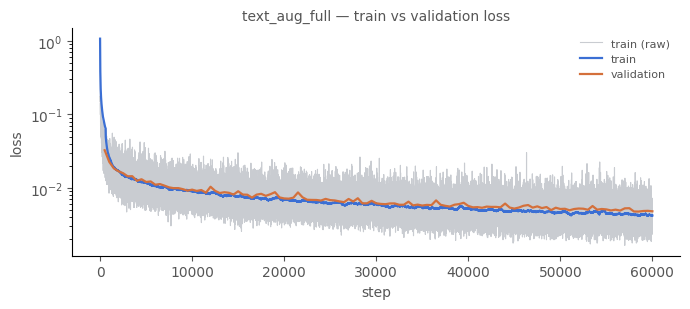

final train 0.0050  |  final val 0.0048  (step 60000)


In [21]:
losses_aug, val_aug = run_aug.load_loss_history()
plot_losses(losses_aug, k=max(1, AUG_STEPS // 100), val_losses=val_aug,
            title=f"{AUG_NAME} — train vs validation loss", path=run_aug.path("loss.png"))

if val_aug:
    last = max(val_aug)
    print(f"final train {losses_aug[-1]:.4f}  |  final val {val_aug[last]:.4f}  (step {last})")

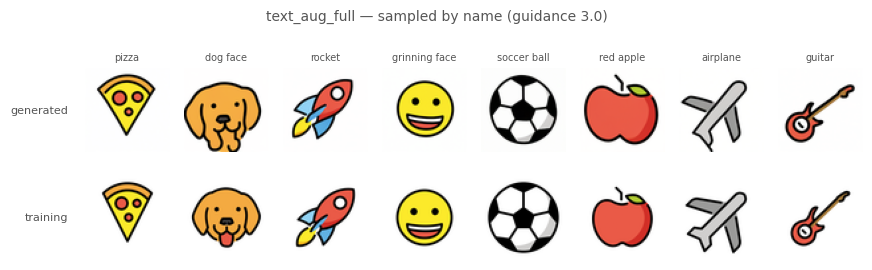

In [24]:
named_aug = generate(ema_aug, diff_aug, preview_labels_aug, guidance_scale=GUIDANCE,
                     ddim_steps=HERO_DDIM_STEPS, device=DEVICE)
run_aug.save_grid(named_aug, "by_name.png", ncols=8)

# The reference is variant 0 — the untouched original of each preview emoji.
first_variant = {}
for i, row in enumerate(ds_aug.meta):
    if row["aug_index"] == "0":
        first_variant[row["name"]] = i
reference_aug = torch.stack([ds_aug[first_variant[n]][0] for n in PREVIEW_NAMES])

# show_pairs titles its columns from the global `names`, which still holds the
# 500-name list from run text_500. Point it at the new vocabulary for the call.
names, names_500 = names_aug, names
try:
    show_pairs(named_aug, reference_aug, preview_labels_aug.tolist(),
               f"{AUG_NAME} — sampled by name (guidance {GUIDANCE})",
               path=run_aug.samples_dir / "by_name_pairs.png")
finally:
    names = names_500

In [ ]:
if "inception" not in globals():
    inception = metrics.InceptionFeatures(DEVICE)

generator = torch.Generator().manual_seed(SEED)
sub = torch.randperm(len(ds_aug), generator=generator)[:AUG_REAL_SAMPLE]
real_aug_images = torch.stack([ds_aug[int(i)][0] for i in sub])
real_aug_labels = torch.tensor([ds_aug.labels[int(i)] for i in sub])
print(f"metric reference: {tuple(real_aug_images.shape)} sampled from the training split")

# One sample per name, as in run text_500.
t0 = time.time()
all_labels_aug = torch.arange(len(names_aug))
fake_aug = generate(ema_aug, diff_aug, all_labels_aug, guidance_scale=GUIDANCE,
                    ddim_steps=DDIM_STEPS, device=DEVICE)
print(f"generated {len(fake_aug)} samples, one per name, in {(time.time() - t0) / 60:.1f} min")
run_aug.save_grid(fake_aug, "all_names.png", ncols=32)

metric reference: (1000, 3, 64, 64) sampled from the training split
generated 1321 samples, one per name, in 8.0 min


In [ ]:
group_idx_aug = {g: i for i, g in enumerate(groups_aug)}
group_of_aug = torch.tensor([group_idx_aug[by_name_aug[n]["group"]] for n in names_aug])

scores_aug = metrics.evaluate(
    real_aug_images, group_of_aug[real_aug_labels],
    fake_aug, group_of_aug[all_labels_aug],
    groups_aug, device=DEVICE, inception=inception, clip=clip,
)

# Name-level conditioning, over all 1321 names at once.
fake_feats_aug = clip.encode_images(fake_aug).cpu()
name_bank_aug = bank_aug[: len(names_aug)]
ranks_aug = (fake_feats_aug @ name_bank_aug.T).argsort(dim=-1, descending=True)
hit_aug = (ranks_aug == all_labels_aug[:, None]).float().argmax(dim=-1)

scores_aug.update({
    "name_clip_score": metrics.clip_score(fake_feats_aug, name_bank_aug[all_labels_aug]),
    "name_top1": float((hit_aug < 1).float().mean()),
    "name_top5": float((hit_aug < 5).float().mean()),
    "name_top10": float((hit_aug < 10).float().mean()),
    "name_chance": 1 / len(names_aug),
    "guidance_scale": GUIDANCE,
    "ddim_steps": DDIM_STEPS,
    "retrieval_text_only": retrieval_aug,
})
run_aug.save_metrics(scores_aug)
print(json.dumps({k: v for k, v in scores_aug.items() if not isinstance(v, dict)}, indent=2))

In [19]:
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
config_aug = run_aug.read_json("config.json")

lines = [
    "# Text-conditioned emoji diffusion on the augmented dataset",
    "",
    f"Generated {time.strftime('%Y-%m-%d %H:%M')} on {DEVICE}"
    + ("  **(QUICK mode — placeholder numbers)**" if QUICK else ""),
    "",
    f"- dataset: `{AUG_GEOM}` — {len(ds_aug)} train / {len(ds_aug_val)} val, "
    f"{ds_aug.num_classes} names ({len(ds_aug) / ds_aug.num_classes:.0f} images per name)",
    "- augmentation: geometry only — rotation +/-12 deg, crop/zoom 0.85-1.10",
    "- holdout: the last 2 of 8 variants of every emoji",
    f"- steps: {config_aug.get('steps_completed', AUG_STEPS)} at batch {AUG_BATCH}"
    f" — {config_aug.get('train_minutes', float('nan')):.1f} min",
    f"- final train loss: {config_aug.get('final_loss', float('nan')):.4f}",
    f"- final val loss: {config_aug.get('final_val_loss', float('nan')):.4f}",
    "",
    "## Prompt -> name retrieval (text only, no images)",
    "",
    f"top-1 {retrieval_aug['top1']:.3f} | top-5 {retrieval_aug['top5']:.3f} | "
    f"top-10 {retrieval_aug['top10']:.3f} over {retrieval_aug['n_candidates']} candidates",
    "",
    "## Generation metrics",
    "",
    "| metric | value |",
    "| --- | --- |",
]
for key in ("fid", "kid_mean", "cmmd", "precision", "recall", "clip_score",
            "clip_accuracy", "clip_accuracy_real", "name_clip_score",
            "name_top1", "name_top5", "name_top10", "name_chance",
            "nn_similarity_mean", "lpips_nn_mean", "lpips_nn_mean_real",
            "perceptual_copy_rate", "pixel_nn_rmse_mean", "pixel_copy_rate",
            "diversity_fake", "diversity_real"):
    value = scores_aug.get(key)
    if isinstance(value, (int, float)):
        lines.append(f"| {key} | {value:.4f} |")
if scores_aug.get("lpips_backend"):
    lines.append(f"| lpips_backend | {scores_aug['lpips_backend']} |")

lines += ["", "## Versus text_500", "",
          f"| metric | {RUN_NAME} | {AUG_NAME} |", "| --- | --- | --- |"]
old_scores = load_metrics([RUN_NAME]).get(RUN_NAME, {})
for key in ("fid", "cmmd", "precision", "recall", "clip_accuracy",
            "name_top1", "name_top5", "name_chance",
            "nn_similarity_mean", "diversity_fake"):
    a, b = old_scores.get(key), scores_aug.get(key)
    if isinstance(a, (int, float)) and isinstance(b, (int, float)):
        lines.append(f"| {key} | {a:.4f} | {b:.4f} |")

lines += ["", "## Figures", ""] + [f"- `{p}`" for p in sorted(run_aug.dir.rglob("*.png"))]

with open(RESULTS / f"summary_{AUG_NAME}.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print("\n".join(lines[:18]))
print(f"\nwrote {RESULTS / f'summary_{AUG_NAME}.md'}")

NameError: name 'scores_aug' is not defined

### What to look for

`text_500` scored `name_top1` 0.006 against a chance of 0.002 — barely above
guessing, with one image per name. Whether eight views per name moves that is
the question this run exists to answer.

Two things make it **not** a clean A/B against `text_500`:

- the name space grew from 500 to 1321, so chance drops from 0.0020 to 0.0008
  and every retrieval number gets harder for reasons that have nothing to do
  with the model;
- the FID reference is 1000 sampled training images rather than all 500, so
  absolute FID is not comparable across the two runs. The `Versus text_500`
  table prints both anyway — read the retrieval and copy rows, not the FID row.

The validation loss is the only number in this notebook that was never trained
on, and `perceptual_copy_rate` is the one that directly answers "is it
generating or remembering", which is the whole reason the augmentation exists.

## Train more, snapshot, then score offline

Continues `runs/text_aug_full/` instead of starting over: it restores the weights if the
kernel is fresh, runs `EXTRA_STEPS` further steps, and **extends** the step
numbering and both loss histories rather than resetting them.

`val_every` and `val_max_images` are left as they were, so every round scores the
same held-out batch with the same fixed noise — otherwise the validation curve
would jump at each resume for reasons that have nothing to do with the model.

Each round ends saved twice: `ckpt.pt` is the rolling copy and carries the
optimiser, so the next round resumes with Adam's moments intact; `SNAPSHOT`
additionally leaves an immutable `ckpt_step<N>.pt`, so a state you liked is never
overwritten later.

It also writes `runs/text_aug_full/eval.json`, which is all `evaluate_run.py` needs to
score any checkpoint of this run later, from a cold shell:

```
python evaluate_run.py text_aug_full                              # the rolling ckpt.pt
python evaluate_run.py text_aug_full --snapshots                  # every archived step
```

Needs §0 and §13's config cell to have been run first — it rebuilds everything else itself.

restored from step 60000
validation: 512 of 2642 images, fixed noise, every 500 steps
step  60500 | epoch   244.9 | loss 0.0042 | val 0.0049 |   1.2 min
step  61000 | epoch   247.0 | loss 0.0042 | val 0.0051 |   3.0 min
step  61500 | epoch   249.0 | loss 0.0042 | val 0.0051 |   4.7 min
step  62000 | epoch   251.0 | loss 0.0043 | val 0.0048 |   6.5 min
step  62500 | epoch   253.0 | loss 0.0042 | val 0.0053 |   8.2 min
step  63000 | epoch   255.1 | loss 0.0043 | val 0.0047 |  10.0 min
step  63500 | epoch   257.1 | loss 0.0041 | val 0.0048 |  11.7 min
step  64000 | epoch   259.1 | loss 0.0042 | val 0.0050 |  13.4 min
step  64500 | epoch   261.1 | loss 0.0042 | val 0.0048 |  15.2 min
step  65000 | epoch   263.2 | loss 0.0040 | val 0.0047 |  16.9 min


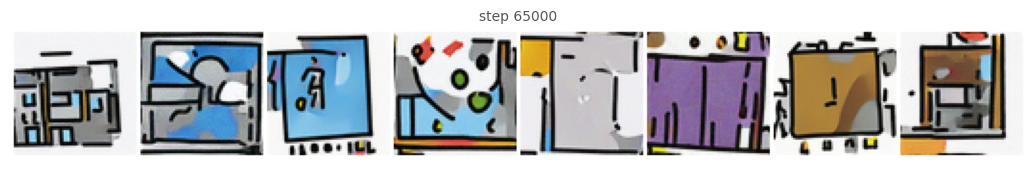

step  65500 | epoch   265.2 | loss 0.0042 | val 0.0047 |  18.7 min
step  66000 | epoch   267.2 | loss 0.0042 | val 0.0046 |  20.5 min
step  66500 | epoch   269.2 | loss 0.0041 | val 0.0047 |  22.3 min
step  67000 | epoch   271.3 | loss 0.0041 | val 0.0047 |  24.0 min
step  67500 | epoch   273.3 | loss 0.0041 | val 0.0048 |  25.7 min
step  68000 | epoch   275.3 | loss 0.0041 | val 0.0054 |  27.5 min
step  68500 | epoch   277.3 | loss 0.0040 | val 0.0045 |  29.2 min
step  69000 | epoch   279.4 | loss 0.0041 | val 0.0047 |  31.0 min
step  69500 | epoch   281.4 | loss 0.0039 | val 0.0048 |  32.7 min
step  70000 | epoch   283.4 | loss 0.0042 | val 0.0048 |  34.5 min


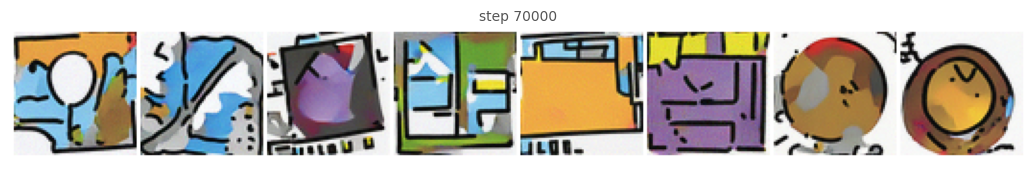

step  70500 | epoch   285.4 | loss 0.0039 | val 0.0045 |  36.3 min
step  71000 | epoch   287.4 | loss 0.0041 | val 0.0048 |  38.0 min
step  71500 | epoch   289.5 | loss 0.0040 | val 0.0046 |  39.8 min
step  72000 | epoch   291.5 | loss 0.0040 | val 0.0048 |  41.5 min
step  72500 | epoch   293.5 | loss 0.0037 | val 0.0051 |  43.3 min
step  73000 | epoch   295.5 | loss 0.0038 | val 0.0048 |  45.0 min
step  73500 | epoch   297.6 | loss 0.0041 | val 0.0046 |  46.8 min
step  74000 | epoch   299.6 | loss 0.0040 | val 0.0045 |  48.5 min
step  74500 | epoch   301.6 | loss 0.0039 | val 0.0045 |  50.3 min
step  75000 | epoch   303.6 | loss 0.0037 | val 0.0046 |  51.8 min


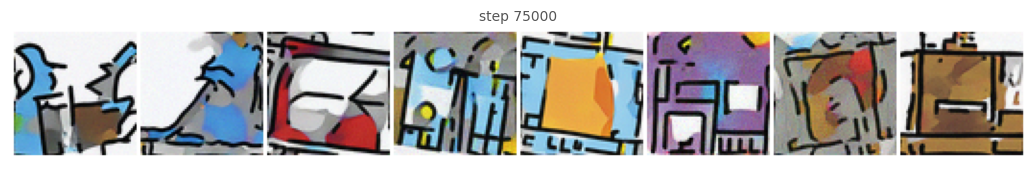

step  75500 | epoch   305.7 | loss 0.0038 | val 0.0048 |  53.0 min
step  76000 | epoch   307.7 | loss 0.0039 | val 0.0047 |  54.2 min
step  76500 | epoch   309.7 | loss 0.0039 | val 0.0046 |  55.4 min
step  77000 | epoch   311.7 | loss 0.0038 | val 0.0045 |  56.5 min
step  77500 | epoch   313.8 | loss 0.0038 | val 0.0045 |  57.6 min
step  78000 | epoch   315.8 | loss 0.0039 | val 0.0047 |  58.8 min
step  78500 | epoch   317.8 | loss 0.0041 | val 0.0046 |  60.0 min
step  79000 | epoch   319.8 | loss 0.0037 | val 0.0045 |  61.1 min
step  79500 | epoch   321.9 | loss 0.0037 | val 0.0044 |  62.3 min
step  80000 | epoch   323.9 | loss 0.0039 | val 0.0045 |  63.4 min


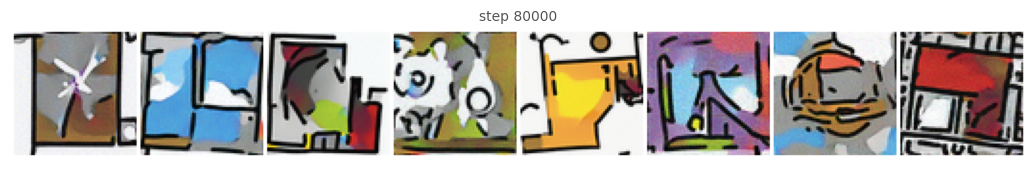

done: 20000 steps in 63.5 min (now at 80000), final loss 0.0031
saved weights -> runs/text_aug_full/ckpt.pt
snapshot -> runs/text_aug_full/ckpt_step080000.pt


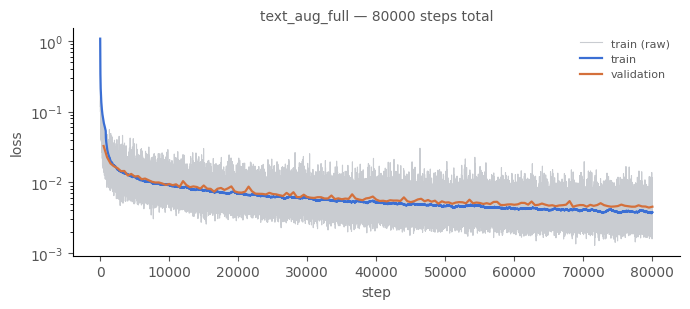


now at 80000 steps.  score it offline with:
    python evaluate_run.py text_aug_full --checkpoint ckpt_step080000.pt


In [20]:
# ── edit me ───────────────────────────────────────────────────────────
EXTRA_STEPS = 20_000
SNAPSHOT    = True     # keep this round's weights under their own name
# ──────────────────────────────────────────────────────────────────────
from dataloader import train_val_split
from evaluate_run import build_model

more_run = Run(AUG_NAME)
more_train, more_val = train_val_split(AUG_GEOM, label_col="name",
                                       holdout="variant", val_variants=2)

name_to_idx = {n: i for i, n in enumerate(more_train.classes)}
more_preview = torch.tensor([name_to_idx[n] for n in PREVIEW_NAMES])

if not {"model_aug", "ema_aug"} <= globals().keys():
    # The CLIP bank is a buffer inside the checkpoint, so build_model restores
    # the exact conditioning space this model was trained on. That removes the
    # bank-mismatch failure the older §12 cell has to guard against.
    checkpoint = more_run.load_checkpoint(map_location=DEVICE)
    model_aug, _ = build_model(checkpoint["model"])
    ema_aug, _ = build_model(checkpoint["ema"])
    model_aug.load_state_dict(checkpoint["model"])
    ema_aug.load_state_dict(checkpoint["ema"])
    model_aug, ema_aug = model_aug.to(DEVICE), ema_aug.to(DEVICE)
    ema_aug.requires_grad_(False)
    ema_aug.eval()
    model_aug.text_dropout = TEXT_DROPOUT

    resume_step, optimizer_state = checkpoint["step"], checkpoint.get("opt")
    print(f"restored from step {resume_step}" + ("" if optimizer_state else
          "  (no optimiser state — Adam restarts, expect a brief loss bump)"))
else:
    resume_step, optimizer_state = more_run.config.get("steps_completed", 0), None
    print(f"continuing the model already in memory, at step {resume_step}")

if model_aug.num_classes != more_train.num_classes:
    raise RuntimeError(
        f"checkpoint conditions on {model_aug.num_classes} names but the dataset has "
        f"{more_train.num_classes}: these are different vocabularies, so resuming "
        "would extend a model whose conditioning no longer matches the labels."
    )

past_losses, past_val = more_run.load_loss_history()

model_aug, ema_aug, losses_aug, diff_aug = train(
    model_aug, more_train, more_run, val_dataset=more_val,
    steps=EXTRA_STEPS, batch_size=AUG_BATCH, lr=LR, timesteps=T,
    ema_decay=EMA_DECAY, log_every=AUG_LOG_EVERY,
    val_every=AUG_VAL_EVERY, val_max_images=AUG_VAL_IMAGES,
    checkpoint_every=AUG_CHECKPOINT_EVERY,
    preview_every=AUG_PREVIEW_EVERY, preview_labels=more_preview,
    preview_ddim_steps=DDIM_STEPS, guidance_scale=GUIDANCE,
    num_workers=NUM_WORKERS, device=DEVICE, seed=SEED,
    ema=ema_aug, start_step=resume_step, optimizer_state=optimizer_state,
    losses=past_losses, val_losses=past_val,
    on_preview=lambda step, imgs, lbls: show_grid(imgs, ncols=8, title=f"step {step}"),
)

total_steps = more_run.read_json("config.json")["steps_completed"]
if SNAPSHOT:
    print("snapshot ->", more_run.save_checkpoint(
        model_aug, ema=ema_aug, step=total_steps, filename=f"ckpt_step{total_steps:06d}.pt"))

# n_fake is null so the evaluator draws one sample per name, which is what makes
# the retrieval numbers comparable with the §13 metrics cell.
more_run.write_json("eval.json", {
    "dataset": AUG_GEOM, "label_col": "name", "holdout": "variant",
    "val_variants": 2, "real_sample": AUG_REAL_SAMPLE, "n_fake": None,
    "guidance": GUIDANCE, "ddim_steps": DDIM_STEPS, "seed": SEED,
})

losses_aug, val_aug = more_run.load_loss_history()
plot_losses(losses_aug, k=max(1, len(losses_aug) // 100), val_losses=val_aug,
            title=f"{AUG_NAME} — {total_steps} steps total", path=more_run.path("loss.png"))

print(f"\nnow at {total_steps} steps.  score it offline with:")
print(f"    python evaluate_run.py {AUG_NAME}"
      + (f" --checkpoint ckpt_step{total_steps:06d}.pt" if SNAPSHOT else ""))